In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import rotation_utils



In [6]:
def generate_matrix_with_outliers(rows, cols, outlier_ratio=0.1, normal_std=1.0, outlier_std=10.0, seed=42):
    """
    Generate a matrix with values sampled from two distinct normal distributions.
    
    Args:
        rows (int): Number of rows
        cols (int): Number of columns
        outlier_ratio (float): Proportion of values that are outliers (0-1)
        normal_std (float): Standard deviation for normal values
        outlier_std (float): Standard deviation for outlier values
        seed (int): Random seed for reproducibility
    
    Returns:
        torch.Tensor: Matrix with outliers
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    # Create base matrix with normal distribution
    matrix = torch.randn(rows, cols) * normal_std
    
    # Create mask for outliers
    total_elements = rows * cols
    num_outliers = int(total_elements * outlier_ratio)
    
    # Randomly select positions for outliers
    outlier_positions = torch.randperm(total_elements)[:num_outliers]
    
    # Convert to 2D indices
    outlier_rows = outlier_positions // cols
    outlier_cols = outlier_positions % cols
    
    # Replace selected positions with outlier values
    outlier_values = torch.randn(num_outliers) * outlier_std
    matrix[outlier_rows, outlier_cols] = outlier_values
    
    return matrix

In [ ]:
def generate_matrix_with_channel_outliers(rows, cols, outlier_channels=None, normal_mean=0.0, normal_std=1.0, 
                                        outlier_mean=100.0, outlier_std=10.0, seed=42):
   
    if seed is not None:
        torch.manual_seed(seed)
    
    # Initialize matrix with normal distribution
    matrix = torch.randn(rows, cols) * normal_std + normal_mean
    
    # Apply outlier distribution to specific channels
    if outlier_channels is not None:
        for channel_idx in outlier_channels:
            if 0 <= channel_idx < cols:
                # Generate outlier values for entire channel
                outlier_values = torch.randn(rows) * outlier_std + outlier_mean
                matrix[:, channel_idx] = outlier_values
            else:
                print(f"Warning: Channel index {channel_idx} is out of range [0, {cols-1}]")
    
    return matrix


In [8]:
def distribution_plot(matrix, title="Matrix Distribution", bins=50):
    """
    Plot the distribution of values in a matrix.
    
    Args:
        matrix (torch.Tensor): Matrix to plot
        title (str): Title for the plot
        bins (int): Number of histogram bins
    """
    values = matrix.flatten().cpu().numpy()
    
    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=bins, alpha=0.7, density=True, edgecolor='black')
    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    
    # Add statistics to the plot
    mean_val = np.mean(values)
    std_val = np.std(values)
    min_val = np.min(values)
    max_val = np.max(values)
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
    plt.text(0.02, 0.98, f'Std: {std_val:.3f}\nMin: {min_val:.3f}\nMax: {max_val:.3f}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.legend()
    plt.tight_layout()
    plt.show()


In [30]:

def plot_channel_statistics(matrix, num_channels_to_show=1024):
    """
    Plot statistics for specific channels to visualize outlier channels.
    
    Args:
        matrix (torch.Tensor): Input matrix
        outlier_channels (list): List of outlier channel indices
        num_channels_to_show (int): Number of channels to display statistics for
    """
    matrix_np = matrix.cpu().numpy()
    
    # Calculate mean and std for each channel
    channel_means = np.mean(matrix_np, axis=0)
    channel_stds = np.std(matrix_np, axis=0)
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Channel means
    plt.subplot(1, 3, 1)
    channels_to_plot = min(num_channels_to_show, matrix.shape[1])
    x_channels = range(channels_to_plot)
    
    plt.bar(x_channels, channel_means[:channels_to_plot], alpha=0.7)
    
    # if outlier_channels:
    #     outlier_in_range = [ch for ch in outlier_channels if ch < channels_to_plot]
    #     print("Outlier channels in range:", outlier_in_range)
    #     if outlier_in_range:
    #         plt.bar(outlier_in_range, channel_means[outlier_in_range], 
    #                color='red', alpha=0.8, label='Outlier Channels')
    
    plt.title('Channel Means')
    plt.xlabel('Channel Index')
    plt.ylabel('Mean Value')
    plt.legend()
    
    # Plot 2: Channel standard deviations
    plt.subplot(1, 3, 2)
    plt.bar(x_channels, channel_stds[:channels_to_plot], alpha=0.7)
    # if outlier_channels:
    #     outlier_in_range = [ch for ch in outlier_channels if ch < channels_to_plot]
    #     if outlier_in_range:
    #         plt.bar(outlier_in_range, channel_stds[outlier_in_range], 
    #                color='red', alpha=0.8, label='Outlier Channels')
    
    plt.title('Channel Standard Deviations')
    plt.xlabel('Channel Index')
    plt.ylabel('Std Value')
    plt.legend()
    
    # Plot 3: Overall distribution
    plt.subplot(1, 3, 3)
    plt.hist(matrix_np.flatten(), bins=50, alpha=0.7, density=True)
    plt.title('Overall Value Distribution')
    plt.xlabel('Value')
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_matrix_3d_bars(matrix, title="3D Matrix Bar Plot", figsize=(12, 10), colormap='viridis'):
    """
    Create a 3D bar plot where the height of each bar represents the matrix value.
    
    Args:
        matrix (torch.Tensor or np.array): Matrix to visualize
        title (str): Title for the plot
        figsize (tuple): Figure size
        colormap (str): Colormap for the bars
    """
    # Convert to numpy if it's a torch tensor
    if hasattr(matrix, 'cpu'):
        matrix_np = matrix.cpu().numpy()
    else:
        matrix_np = matrix
    
    # Get matrix dimensions
    rows, cols = matrix_np.shape
    
    # Create the figure and 3D axis
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Create coordinate arrays for bar positions
    xpos = []
    ypos = []
    zpos = []
    dx = []
    dy = []
    dz = []
    colors = []
    
    # Normalize colors based on matrix values
    norm = plt.Normalize(vmin=matrix_np.min(), vmax=matrix_np.max())
    cmap = plt.cm.get_cmap(colormap)
    
    for i in range(rows):
        for j in range(cols):
            xpos.append(j)  # Column position
            ypos.append(i)  # Row position
            zpos.append(0)  # Base at z=0
            dx.append(0.8)  # Bar width in x direction
            dy.append(0.8)  # Bar width in y direction
            dz.append(abs(matrix_np[i, j]))  # Bar height (absolute value)
            colors.append(cmap(norm(matrix_np[i, j])))
    
    # Create the 3D bar plot
    bars = ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, alpha=0.8)
    
    # Set labels and title
    ax.set_xlabel('Column Index')
    ax.set_ylabel('Row Index')
    ax.set_zlabel('Matrix Value')
    ax.set_title(title)
    
    # Add colorbar - specify the axes explicitly
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(matrix_np.flatten())
    fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=5)
    
    # Add statistics text
    stats_text = f'Min: {matrix_np.min():.3f}\nMax: {matrix_np.max():.3f}\nMean: {matrix_np.mean():.3f}\nStd: {matrix_np.std():.3f}'
    ax.text2D(0.02, 0.98, stats_text, transform=ax.transAxes, 
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

Original matrix shape: torch.Size([20, 16])


/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_263178/1168966909.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap)


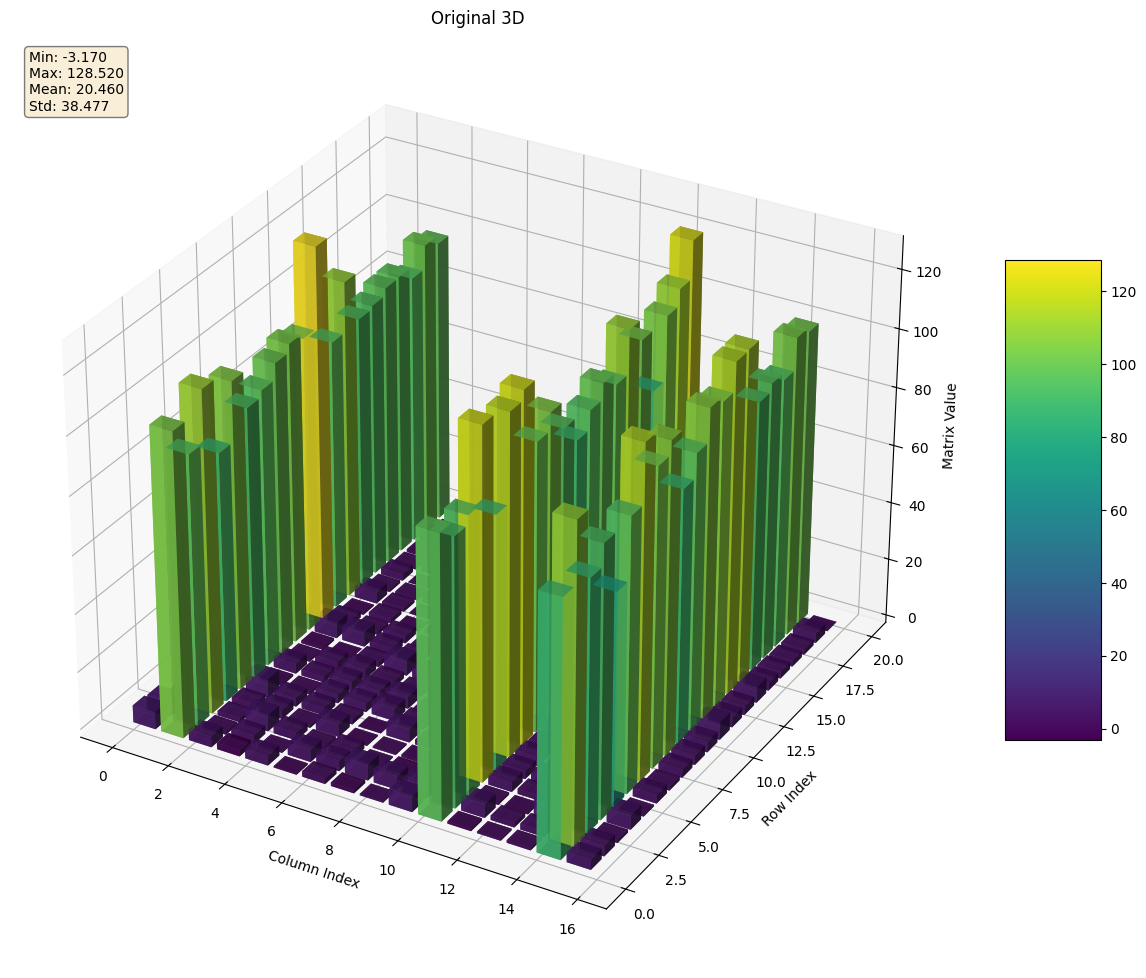

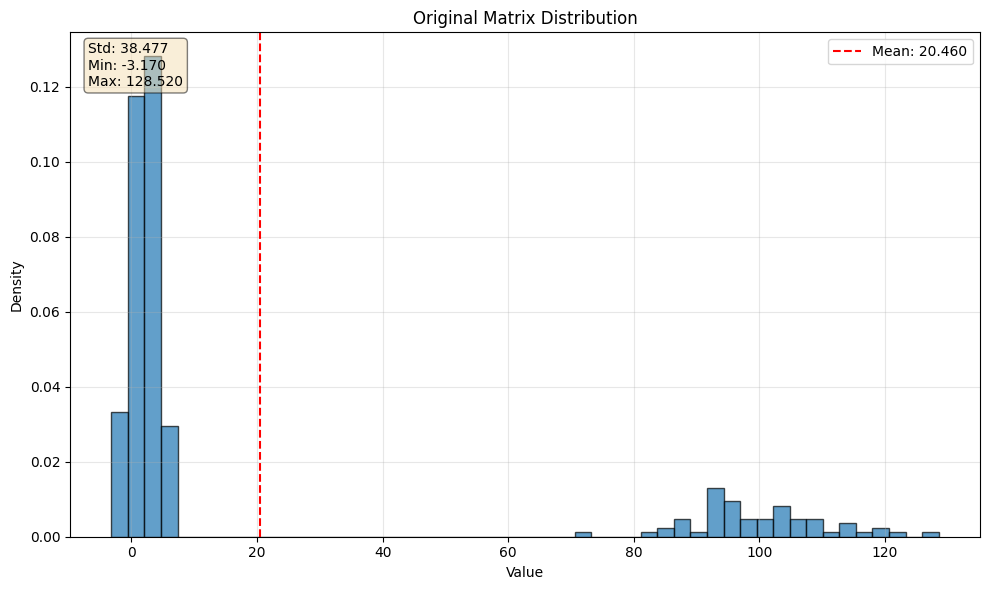

Hadamard matrix shape: torch.Size([16, 16])


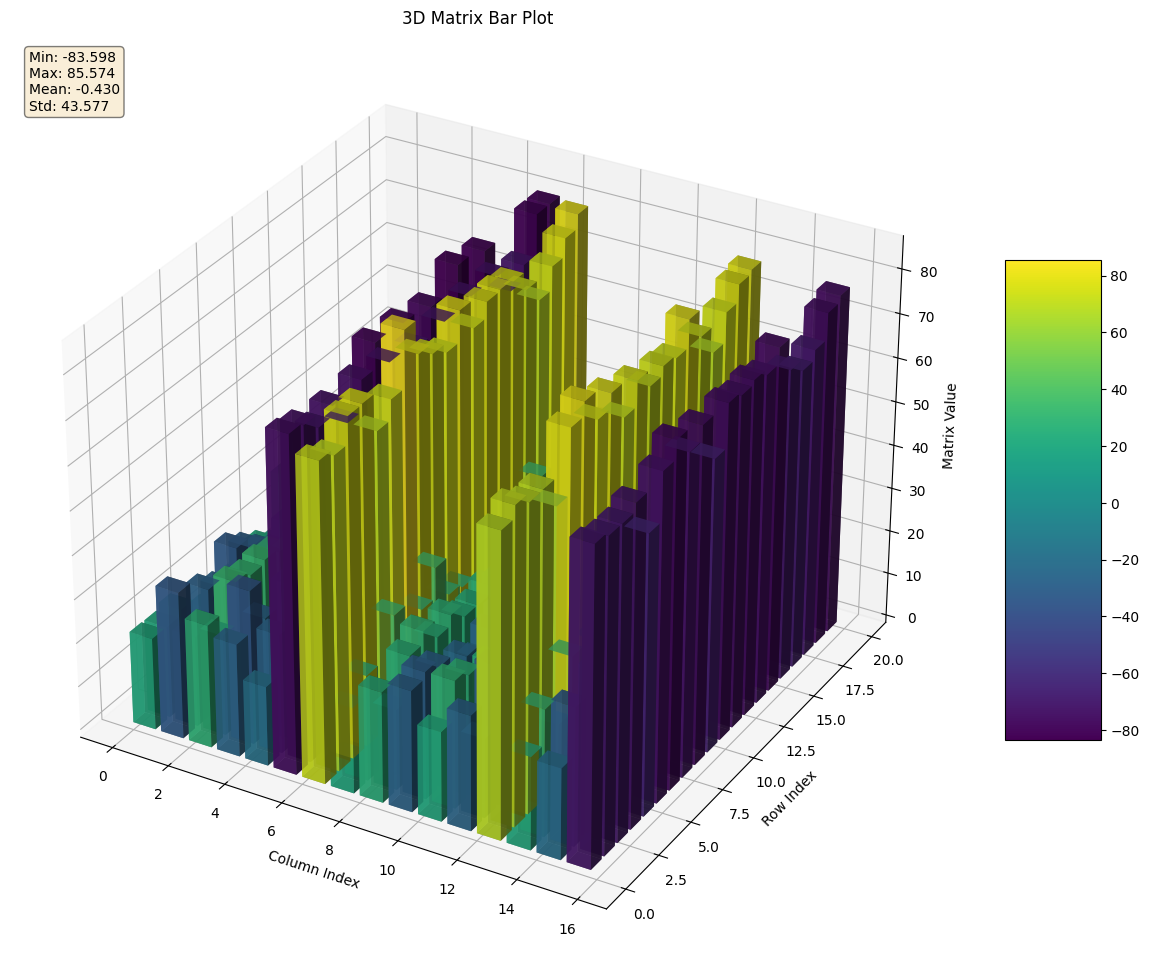

/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_263178/3436955976.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_263178/3436955976.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


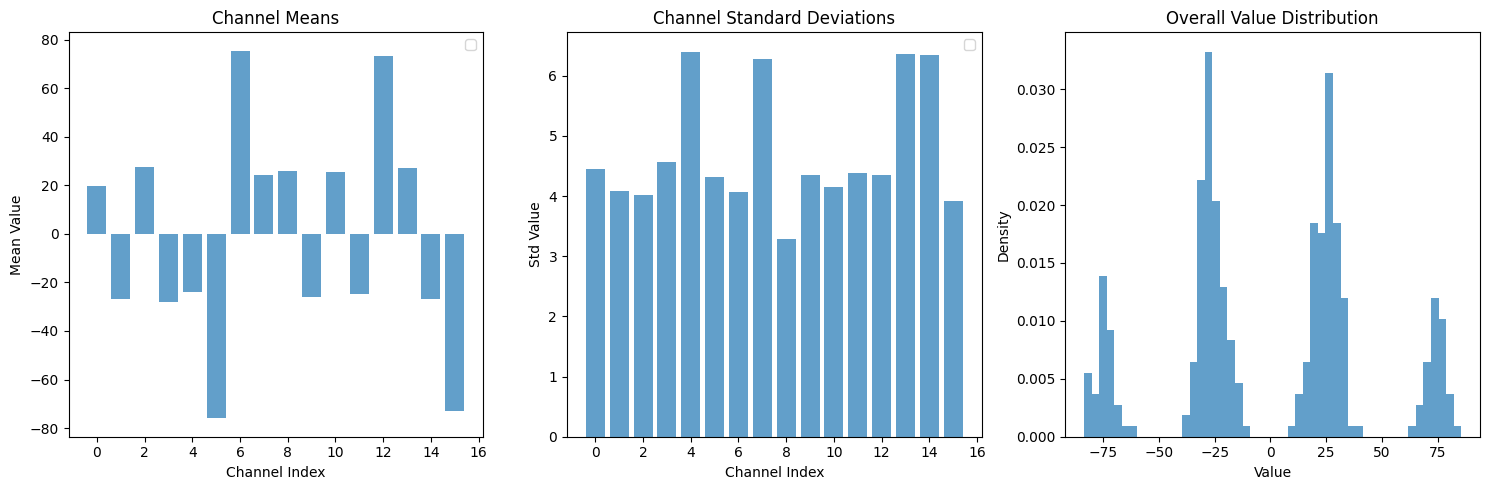

After 1 rotation(s) - Mean: -0.429809, Std: 43.644852
Min: -83.598107, Max: 85.573915
--------------------------------------------------


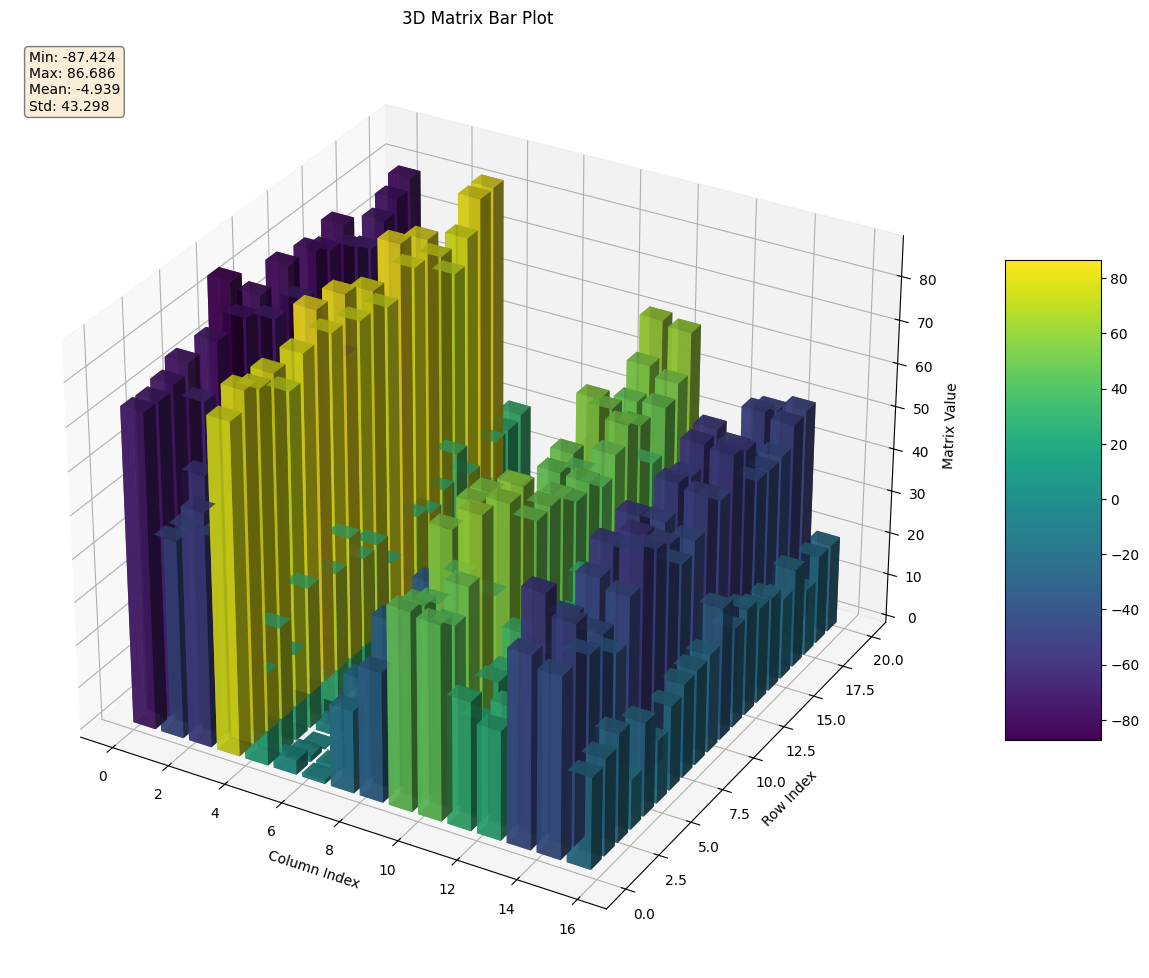

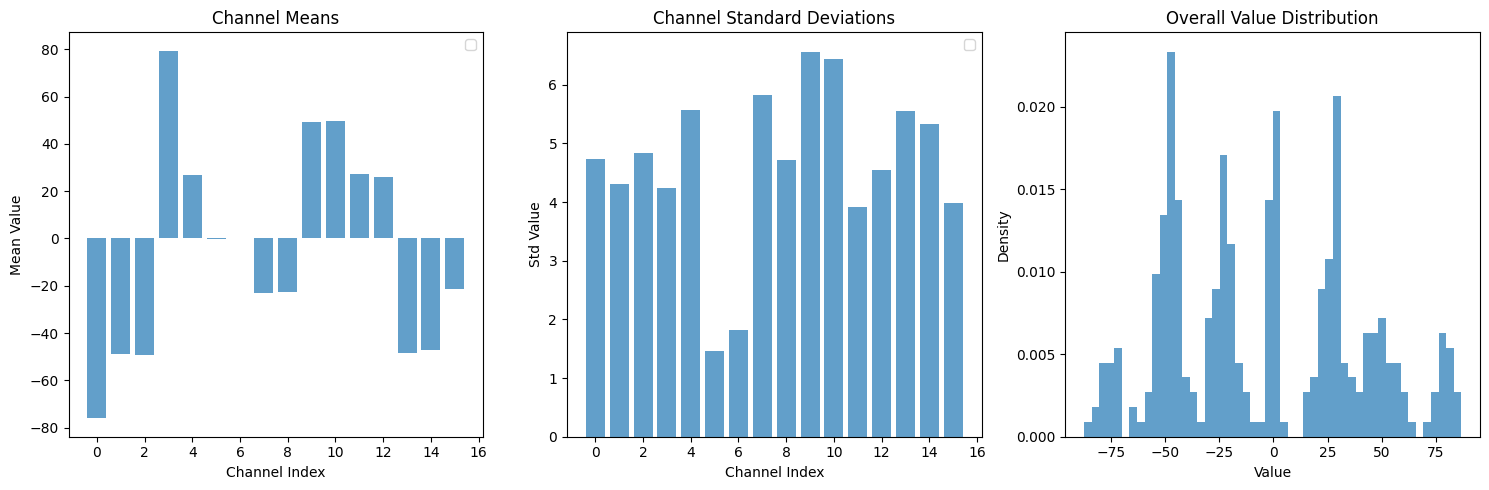

After 2 rotation(s) - Mean: -4.939072, Std: 43.365741
Min: -87.424313, Max: 86.685716
--------------------------------------------------


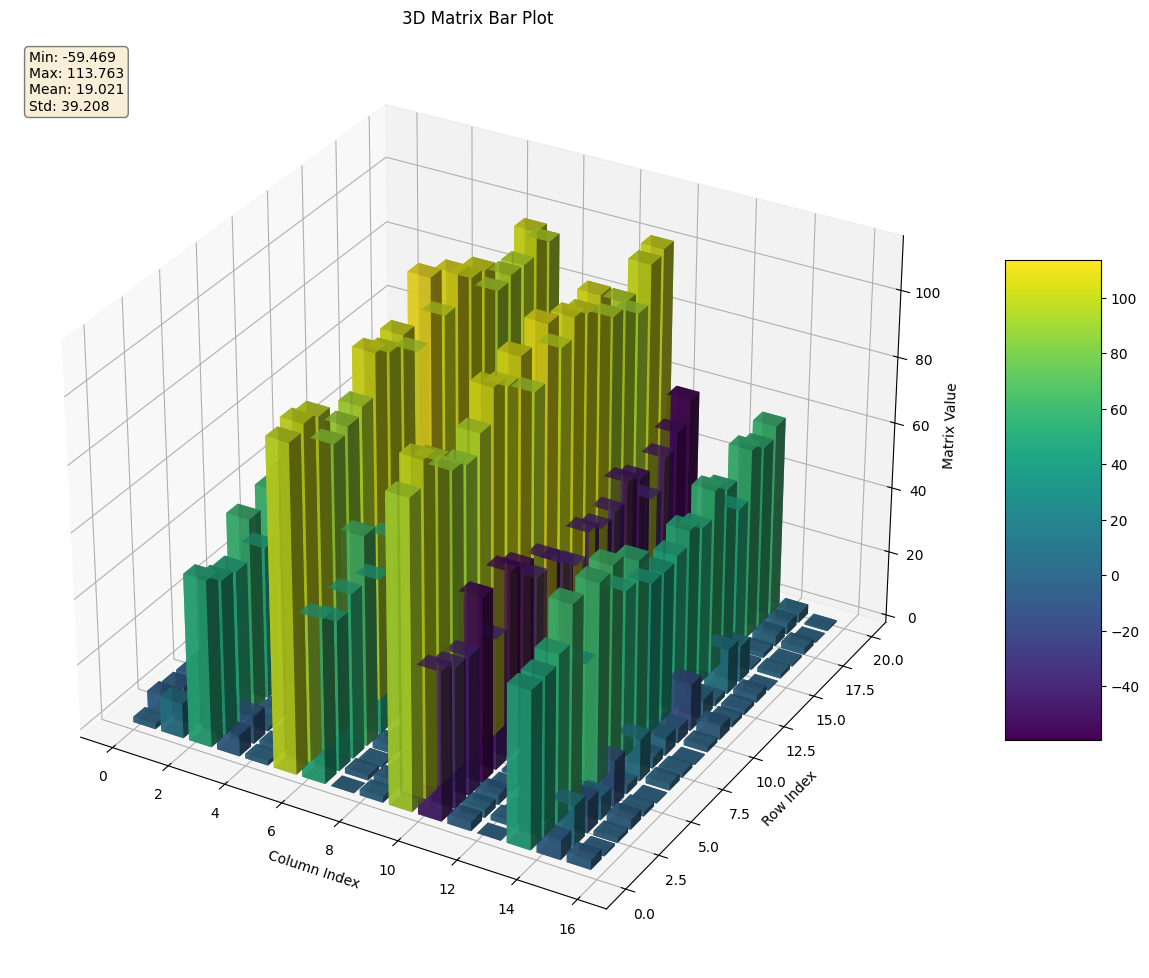

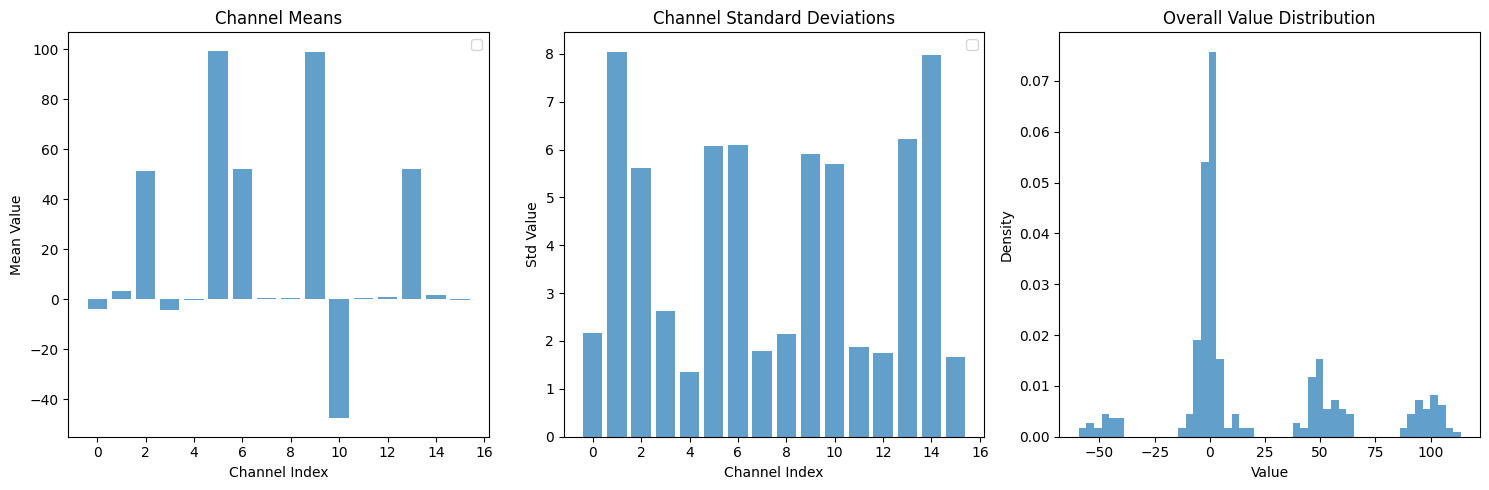

After 3 rotation(s) - Mean: 19.021039, Std: 39.269890
Min: -59.469243, Max: 113.763202
--------------------------------------------------


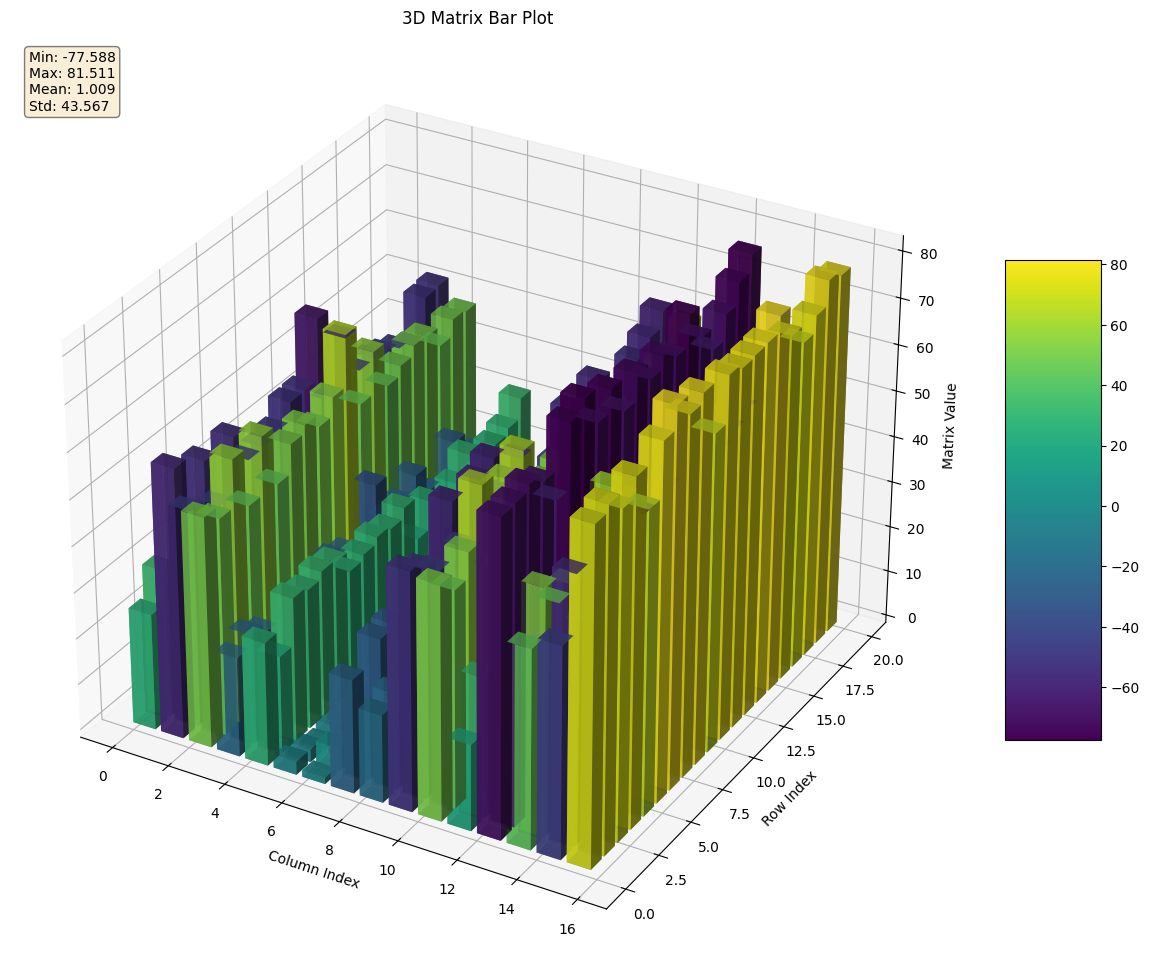

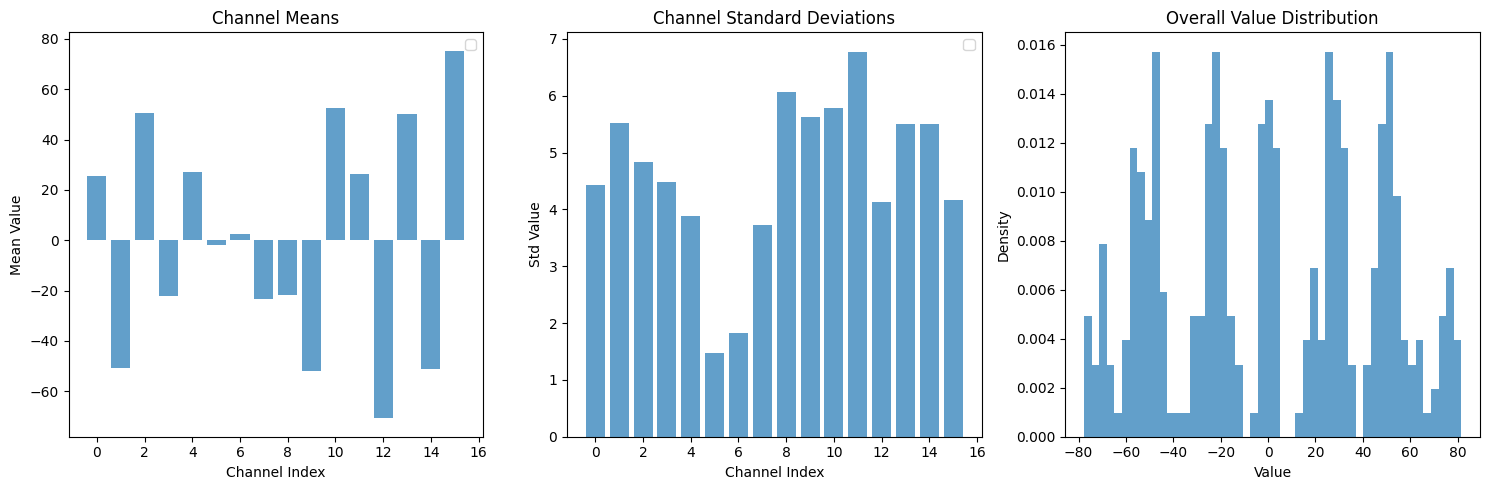

After 4 rotation(s) - Mean: 1.008752, Std: 43.635280
Min: -77.588349, Max: 81.510960
--------------------------------------------------


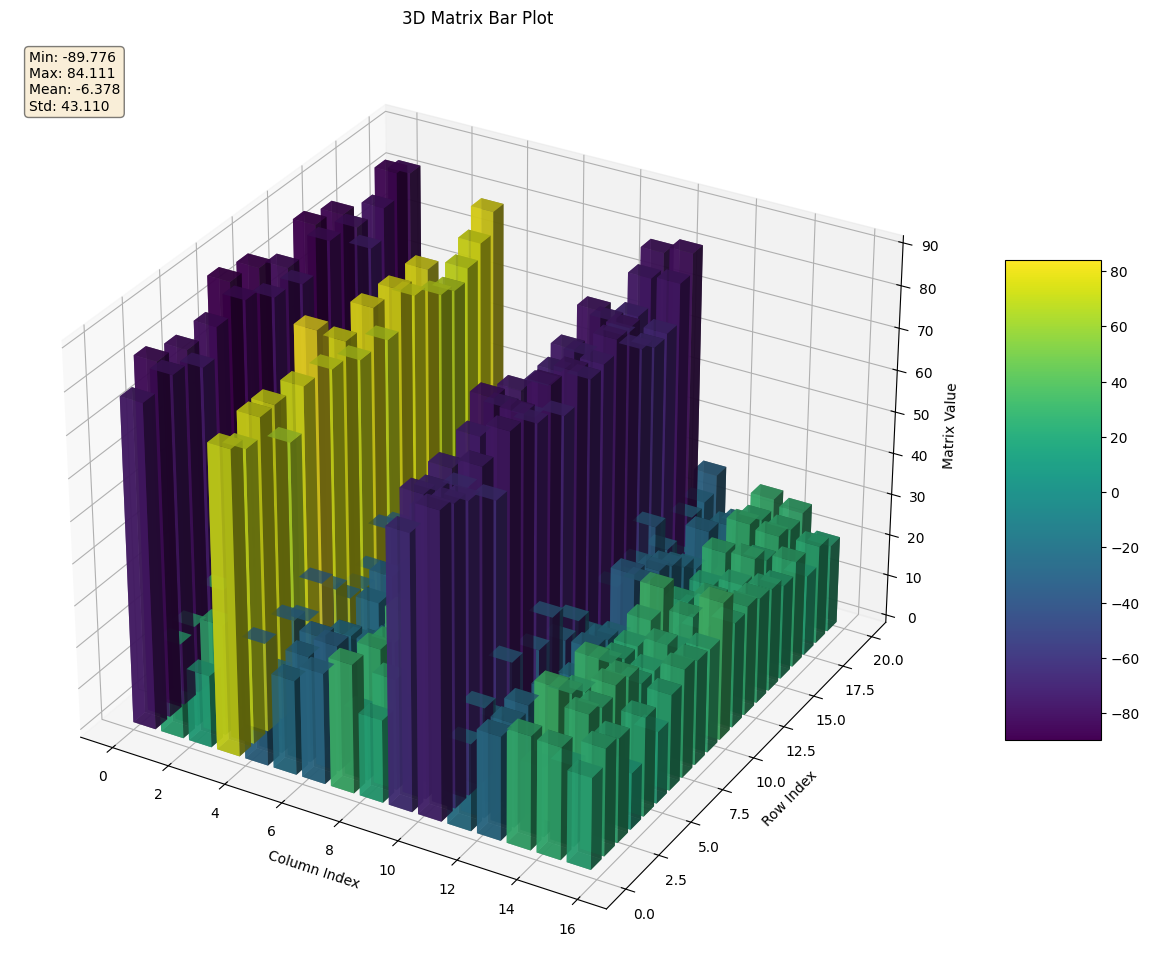

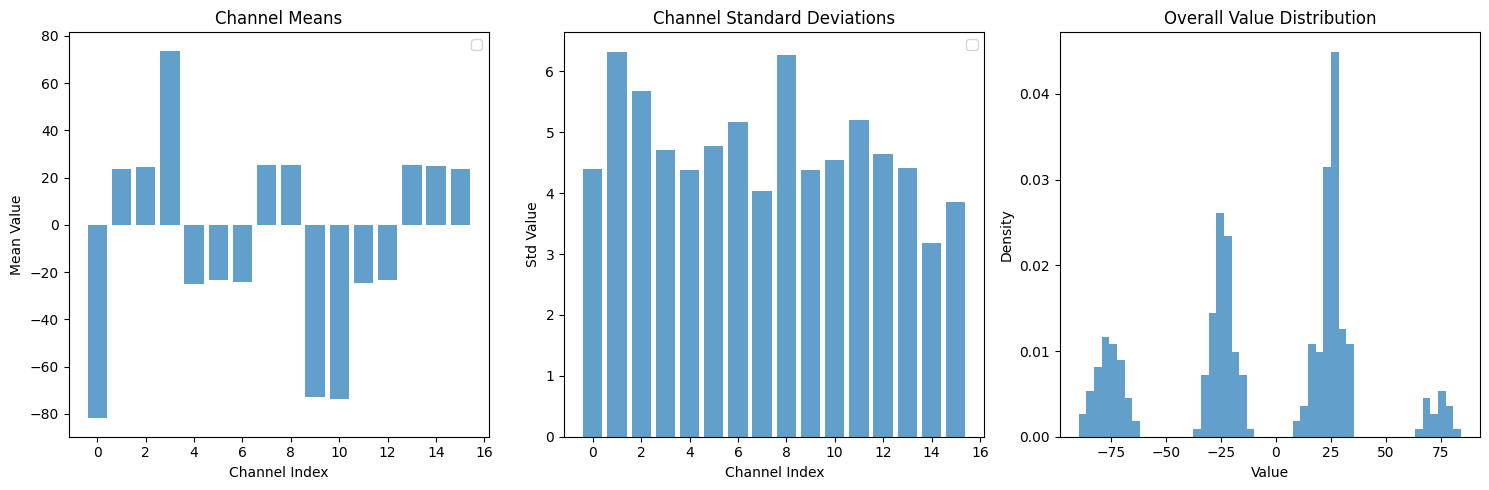

After 5 rotation(s) - Mean: -6.377633, Std: 43.177039
Min: -89.775520, Max: 84.111311
--------------------------------------------------


In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
channels = 16
row_channels = 20
# Define which channels should be outliers
outlier_channels = [1,10,14] 

# Generate matrix with channel-specific outliers
test_matrix = generate_matrix_with_channel_outliers(
    rows=row_channels, 
    cols=channels, 
    outlier_channels=outlier_channels,
    normal_mean=2.0,
    normal_std=2.0,
    outlier_mean=100.0,
    outlier_std=10.0,
    seed=seed
).to(device).double()
print(f"Original matrix shape: {test_matrix.shape}")
plot_matrix_3d_bars(test_matrix,"Original 3D")
distribution_plot(test_matrix, "Original Matrix Distribution")

# Generate Hadamard matrix
hadamard_matrix = rotation_utils.get_orthogonal_matrix(
    size=channels, 
    mode='hadamard', 
    device=device, 
    seed=seed
)

print(f"Hadamard matrix shape: {hadamard_matrix.shape}")

# Apply multiple Hadamard rotations and plot distributions
current_matrix = test_matrix.clone()
num_rotations = 5

for i in range(1, num_rotations + 1):
    # Apply Hadamard rotation
    current_matrix = torch.matmul(current_matrix, hadamard_matrix)
    plot_matrix_3d_bars(current_matrix)
    plot_channel_statistics(current_matrix, num_channels_to_show=channels)
    # distribution_plot(
    #     current_matrix, 
    #     f"Distribution after {i} Hadamard rotation{'s' if i > 1 else ''}"
    # )
    
    print(f"After {i} rotation(s) - Mean: {current_matrix.mean():.6f}, Std: {current_matrix.std():.6f}")
    print(f"Min: {current_matrix.min():.6f}, Max: {current_matrix.max():.6f}")
    print("-" * 50)


Original matrix shape: torch.Size([100, 64])


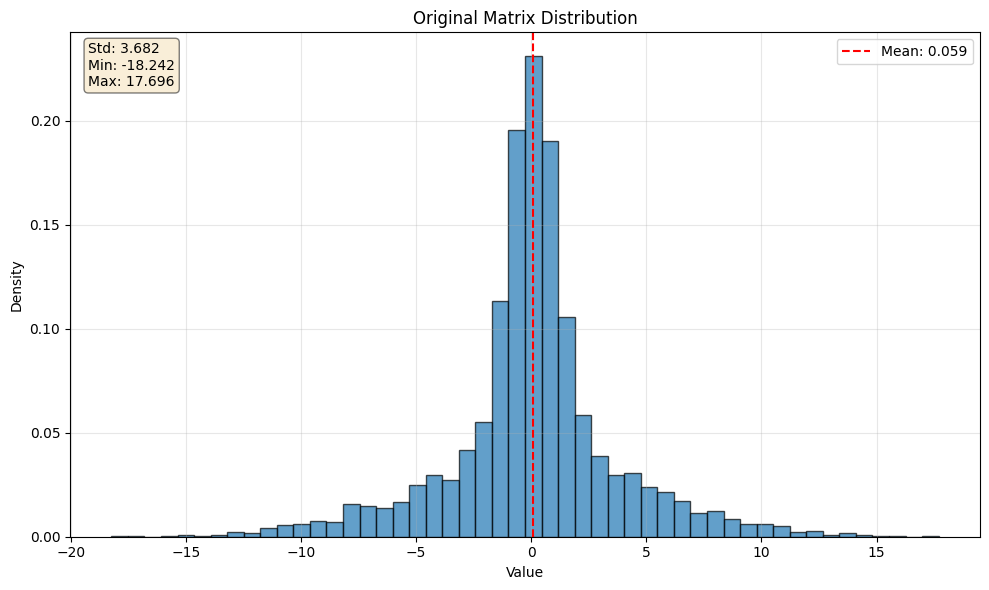

Hadamard matrix shape: torch.Size([64, 64])


/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_263178/3436955976.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_263178/3436955976.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


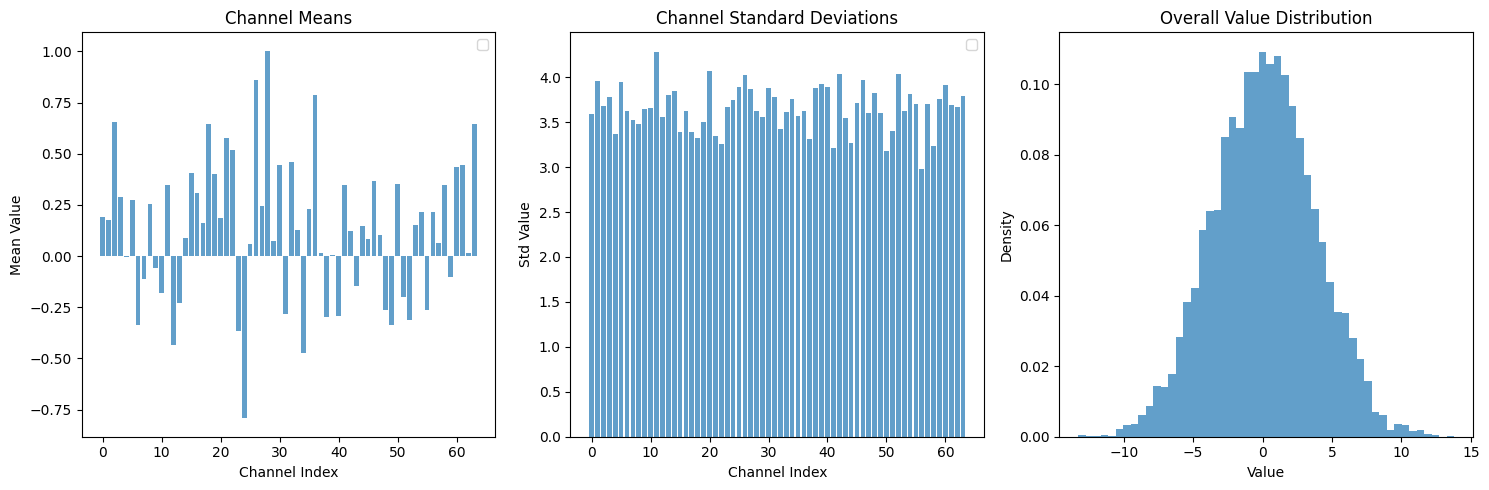

After 1 rotation(s) - Mean: 0.130403, Std: 3.680329
Min: -13.290229, Max: 13.820245
--------------------------------------------------


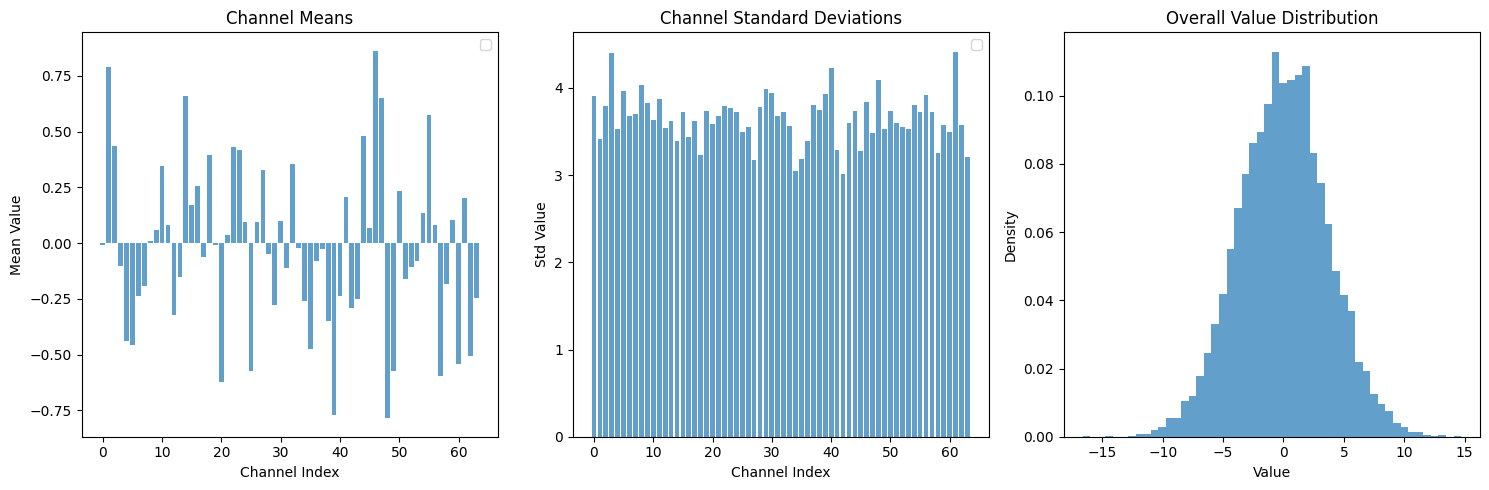

After 2 rotation(s) - Mean: -0.023729, Std: 3.682562
Min: -16.622758, Max: 14.707519
--------------------------------------------------


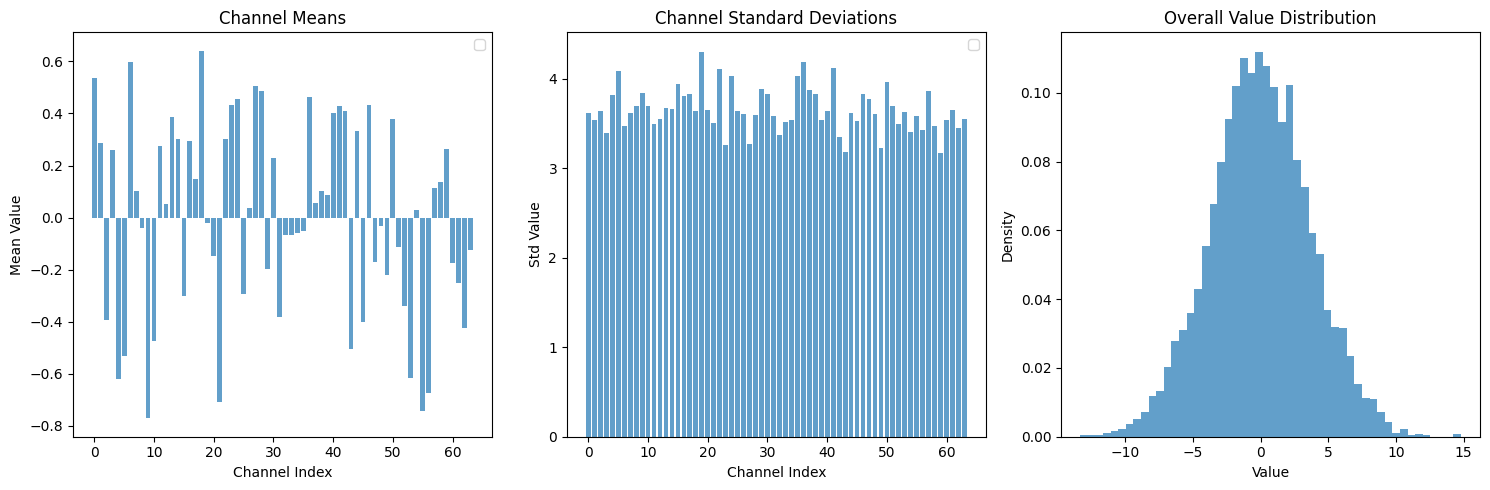

After 3 rotation(s) - Mean: 0.000863, Std: 3.682639
Min: -13.323166, Max: 14.794383
--------------------------------------------------


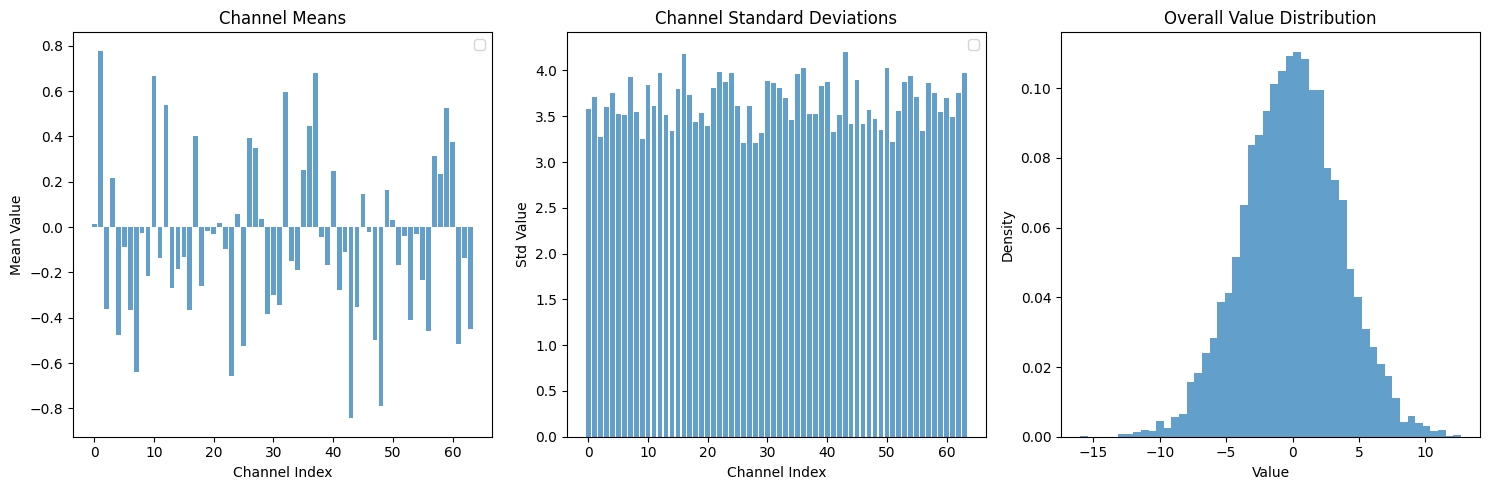

After 4 rotation(s) - Mean: -0.067161, Std: 3.682026
Min: -16.012253, Max: 12.693310
--------------------------------------------------


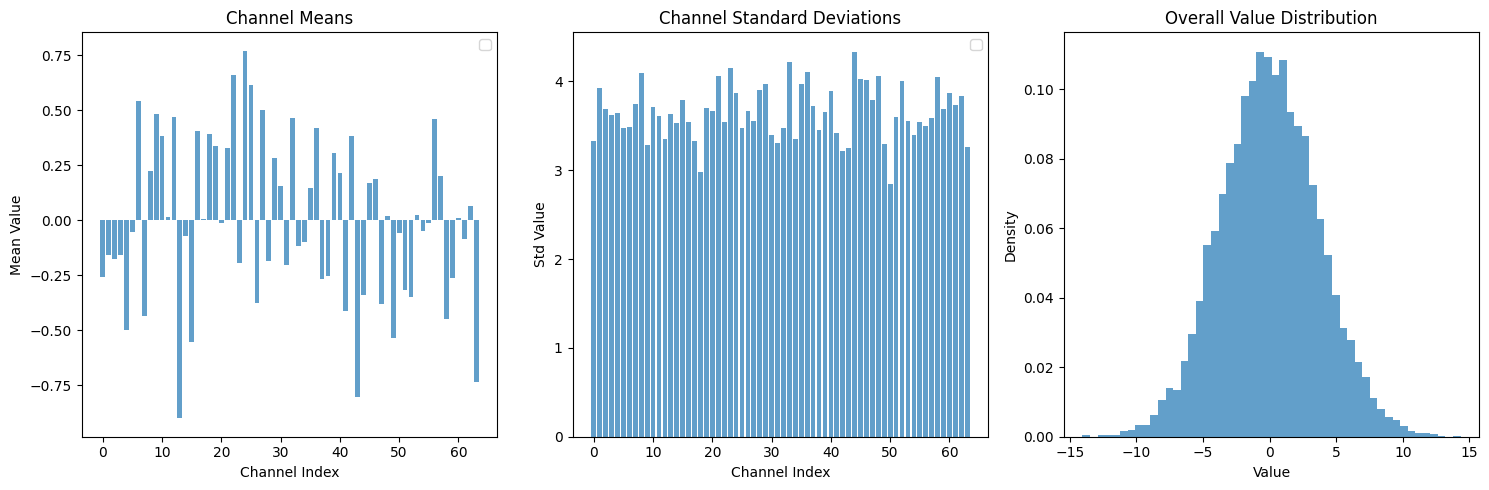

After 5 rotation(s) - Mean: -0.001792, Std: 3.682638
Min: -14.058639, Max: 14.338931
--------------------------------------------------


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
channels =64
row_channels = 100
# Generate test matrix with outliers
test_matrix = generate_matrix_with_outliers(
    rows=row_channels, 
    cols=channels, 
    outlier_ratio=0.5, 
    normal_std=1.0, 
    outlier_std=10.0, 
    seed=seed
).to(device).double()

print(f"Original matrix shape: {test_matrix.shape}")
distribution_plot(test_matrix, "Original Matrix Distribution")

# Generate Hadamard matrix
hadamard_matrix = rotation_utils.get_orthogonal_matrix(
    size=channels, 
    mode='hadamard', 
    device=device, 
    seed=seed
)

print(f"Hadamard matrix shape: {hadamard_matrix.shape}")

# Apply multiple Hadamard rotations and plot distributions
current_matrix = test_matrix.clone()
num_rotations = 5

for i in range(1, num_rotations + 1):
    # Apply Hadamard rotation
    current_matrix = torch.matmul(current_matrix, hadamard_matrix)
    
    plot_channel_statistics(current_matrix, num_channels_to_show=channels)
    # distribution_plot(
    #     current_matrix, 
    #     f"Distribution after {i} Hadamard rotation{'s' if i > 1 else ''}"
    # )
    
    print(f"After {i} rotation(s) - Mean: {current_matrix.mean():.6f}, Std: {current_matrix.std():.6f}")
    print(f"Min: {current_matrix.min():.6f}, Max: {current_matrix.max():.6f}")
    print("-" * 50)